The returns in the Geometric Brownian Motion model are log normal and this is quite useful as it allows for closed for solutions. However as we see in the code above, we have to explictly compute stock paths using the discrete time steps for the CEV model.

The same is true for pricing of Call/Put options. In GBM we have an explict formula for the BS price of a call/put option in terms of the Cumulative Distribution Function of $\mathcal N(0,1)$. 

However, for CEV we shall instead find the price using the base assumption that the price of a call/put option is the expected value of the portfolio with the option discounted to current time. To find this expected value however, we shall use Monte Carlo methods, rather than a closed form solution.

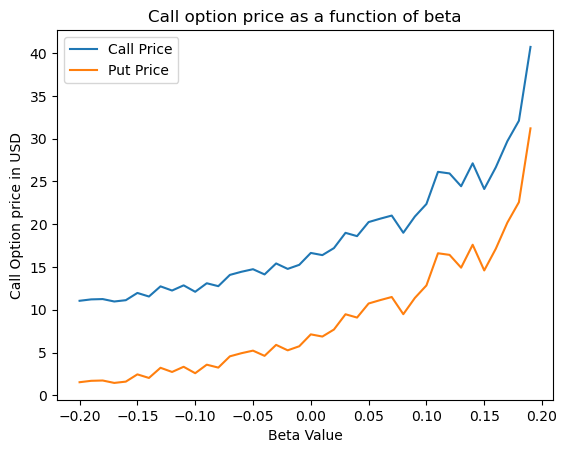

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, poisson
import yfinance as yf
from scipy.optimize import least_squares
S0 = 100
K = 100
T = 1
N = 252
sigma = 0.3
n_paths = 1000
r = 0.10 
dt = T / N

def Call_Price(beta=0):
    Z = np.random.randn(n_paths, N)
    paths = np.zeros((n_paths, N + 1))
    paths[:, 0] = S0

    for t in range(N):
        S_t = paths[:, t]

        #Next discrete step using our standard normal distribution and current stock price (Markov process)
        paths[:, t+1] = S_t + (r * S_t * dt + sigma * (S_t ** (beta+1)) * np.sqrt(dt) * Z[:, t])

        #We don't want stock value to go below 0
        paths[:, t+1] = np.maximum(paths[:, t+1], 0)

    Value_at_expiry = np.exp(-r*T)*np.maximum(0,paths[:,-1]-K) #value at expiry discounted to current time.
    return np.mean(Value_at_expiry)
#We shall generate stock paths corresponding to different values of the parameter \beta
betas = np.arange(-0.2,0.2,0.01)
mean_call_price = []
for b in betas:
    mean_call_price.append(Call_Price(b))
mean_call_price = np.array(mean_call_price) 
#Using Put/Call Partity we can also find the BS put price.
mean_put_price =  mean_call_price + K * np.exp(-r * T) - S0  
plt.plot( betas, mean_call_price, label='Call Price')
plt.plot( betas, mean_put_price, label = 'Put Price')
plt.legend()
plt.title(f'Call option price as a function of beta')
plt.ylabel('Call Option price in USD')
plt.xlabel('Beta Value')
plt.show()
    

In [2]:
# We can use the BS Put/Call price for GBM from lecture and compare our answers for beta = 0
def bs_call(S,K,sigma,t,r):
    d1 = (np.log(S/K)+(r+(0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)

    call_price = S*norm.cdf(d1)-np.exp(-r*t)*K*norm.cdf(d2)

    return call_price

def bs_put(S,K,sigma,t,r):
    d1 = (np.log(S/K)+(r+(0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)

    put_price = -S*norm.cdf(-d1)+np.exp(-r*t)*K*norm.cdf(-d2)

    return put_price
print(f'The BS Call price for GBM from to Closed form solution is {bs_call(S0,K,sigma,T,r):.4f}')
print(f'The Monte Carlo simulation with beta = 0 give us a BS call price of {mean_call_price[(len(betas)+1)//2]:.4f}')
print(f'The BS Put price for GBM from to Closed form solution is {bs_put(S0,K,sigma,T,r):.4f}')
print(f'The Monte Carlo simulation with beta = 0 give us a BS put price of {mean_put_price[(len(betas)+1)//2]:.4f}')

The BS Call price for GBM from to Closed form solution is 16.7341
The Monte Carlo simulation with beta = 0 give us a BS call price of 16.6433
The BS Put price for GBM from to Closed form solution is 7.2179
The Monte Carlo simulation with beta = 0 give us a BS put price of 7.1271
